# Критерії випадковості та сезонності часових рядів

In [8]:
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

import numpy as np
import polars as pl
from scipy.signal import find_peaks
from scipy.stats import linregress, norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.linear_model import LinearRegression

STAND_QUANT = norm.ppf(0.95)

In [9]:
@dataclass
class TimeSeries:
    file_path: str
    series_col_name: str
    time_col_name: str
    time_format: str
    dataset: Optional[pl.DataFrame] = None

    def __post_init__(self):
        self.dataset = self._load_time_series()

    @property
    def series(self) -> pl.Series:
        return self.dataset[self.series_col_name]

    @property
    def times(self) -> pl.Series:
        return self.dataset[self.time_col_name]

    def _load_time_series(self) -> pl.DataFrame:
        if self.file_path.endswith('.csv'):
            return (
                pl.read_csv(self.file_path, try_parse_dates=True)
                .with_columns(pl.col(self.time_col_name).str.to_datetime(self.time_format))
                .sort(self.time_col_name)
            )
        raise TypeError(f"Unexpected file format: {self.file_path.split('.')[-1]}.")

    @staticmethod
    def check_for_randomness(stat_value: int):
        if abs(stat_value) <= STAND_QUANT:
            print("Часовий ряд ВИПАДКОВИЙ")
        else:
            print("Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.")

    def plot_series(self) -> None:
        plt.plot(self.times, self.series)
        plt.xlabel("Times")
        plt.ylabel("Series")
        plt.grid(True)
        plt.show()

    def plot_acf(self, series: Optional[np.ndarray], lags: Optional[int] = None) -> None:
        if series is None:
            series = self.series

        if lags is None:
            lags = len(series) - 1
        plot_acf(series, lags=lags)
        plt.title("Корелограма")
        plt.show()

    def sign_test(self, series: Optional[pl.Series] = None) -> float:
        if series is None:
            series = self.series

        signs = np.sign(np.diff(series))
        signs = signs[signs != 0]

        c = np.sum(signs[1:] != signs[:-1])
        n = len(signs)
        expected = (n - 1) / 2
        variance = (n + 1) / 12

        return (c - expected) / np.sqrt(variance)

    def record_test(self, with_plot: bool = True) -> tuple[float, float]:
        positive_records = []
        negative_records = []

        max_value = self.series[0]
        min_value = self.series[0]

        for idx in range(1, len(self.series)):
            value = self.series[idx]
            if self.series[idx] > max_value and self.series[idx - 1] <= value >= self.series[idx + 1]:
                positive_records.append((idx, value))
                max_value = value

            if value < min_value and self.series[idx - 1] >= value <= self.series[idx + 1]:
                negative_records.append((idx, value))
                min_value = value

        l = len(negative_records)
        m = len(positive_records)
        n = len(time_series.series)
        d = m - l
        s = m + l

        d_d = sum(2 / i for i in range(2, n + 1))
        d_s = sum((2 / i) - (4 / pow(i, 2)) for i in range(2, n + 1))
        stat_1 = d / np.sqrt(d_d)
        stat_2 = (s - d_d) / np.sqrt(d_s)
        if with_plot:
            plt.plot(time_series.series, label='Часовий ряд')
            plt.scatter(*zip(*positive_records), color='g', label='Позитивні рекорди', zorder=2, s=10)
            plt.scatter(*zip(*negative_records), color='r', label='Негативні рекорди', zorder=2, s=10)
            plt.legend()
            plt.title("Рекордні значення в часому ряді")
            plt.show()
        return stat_1, stat_2

    def linear_trend(self) -> np.ndarray:
        """
        Обчислює лінійний тренд часового ряду у вигляді прямої y = a + bx.

        :return: Коефіцієнти (slope b, intercept a)
        """

        y = self.series.to_numpy()
        x = np.arange(len(y))
        slope, intercept, *_ = linregress(x, y)

        trend_line = intercept + slope * x

        return trend_line

    def exponential_trend(self) -> np.ndarray:
        """
        Оцінює параметри експоненціального тренду u_t = a_0 * a_1^t
        шляхом лінеаризації: ln(u_t) = ln(a_0) + ln(a_1) * t

        :return: Параметри a_0, a_1
        """

        y = self.series.to_numpy()
        if np.any(y <= 0):
            raise ValueError("Усі значення ряду мають бути додатні для логарифмування.")

        x = np.arange(len(y))
        log_y = np.log(y)

        slope, intercept, *_ = linregress(x, log_y)
        a_0 = np.exp(intercept)
        a_1 = np.exp(slope)
        trend_line = a_0 * (a_1 ** x)
        return trend_line

    def quadratic_trend(self) -> np.ndarray:
        """
        Оцінює квадратичний тренд часового ряду: y = a + bt + ct²
        :return: Массив значень тренду
        """

        y = self.series.to_numpy()
        x = np.arange(len(y))
        X = np.vstack([np.ones_like(x), x, x ** 2]).T
        coeffs = np.linalg.lstsq(X, y, rcond=None)[0]
        trend_line = coeffs[0] + coeffs[1] * x + coeffs[2] * x ** 2
        return trend_line

    def show_trends(self, trend_dict: dict[str, np.ndarray]) -> None:
        plt.plot(self.times, self.series.to_numpy(), label="Часовий ряд")
        for label, trend_line in trend_dict.items():
            plt.plot(self.times, trend_line, label=label, linestyle='--')
        plt.title("Тренд")
        plt.grid(True)
        plt.legend()
        plt.show()

    def compare_trend_models(self, trend_dict: dict[str, np.ndarray]) -> dict:
        """
        Порівнює кілька трендових моделей за допомогою коефіцієнта детермінації R².

        :param trend_dict: Словник {назва_моделі: прогнозовані_значення}
        :return: dict з R² для кожної моделі
        """

        results = {}
        real_series = self.series.to_numpy()
        ss_tot = np.sum((real_series - np.mean(real_series)) ** 2)

        for name, predicted in trend_dict.items():
            ss_res = np.sum((real_series - predicted) ** 2)
            r2 = 1 - ss_res / ss_tot
            results[f"{name} R2"] = r2

        return results

    def exponential_smoothing(self, alpha: float = 0.3, with_plot: bool = True, replace_real_value: bool = True) -> np.ndarray:
        """
        Застосовує експоненціальне згладжування до часового ряду.

        :param alpha: Коефіцієнт згладжування (0 < alpha ≤ 1)
        :param with_plot: Чи виводити графік згладженого ряду
        :return: Згладжений часовий ряд у вигляді numpy масиву
        """
        if not (0 < alpha <= 1):
            raise ValueError("Параметр alpha має бути у межах (0, 1].")

        y = self.series.to_numpy()
        smoothed = np.zeros_like(y)
        smoothed[0] = y[0]

        for t in range(1, len(y)):
            smoothed[t] = alpha * y[t] + (1 - alpha) * smoothed[t - 1]

        if with_plot:
            plt.plot(self.times, y, label="Оригінальний ряд")
            plt.plot(self.times, smoothed, label=f"Експоненційне згладжування (α={alpha})")
            plt.legend()
            plt.grid(True)
            plt.title("Експоненційне згладжування")
            plt.show()

        if replace_real_value:
            self.dataset = self.dataset.with_columns(pl.lit(smoothed).alias(self.series_col_name))

        return smoothed

    def remove_trend(self, trend_line: np.ndarray, with_plot: bool = True) -> np.ndarray:
        residuals = self.series.to_numpy() - trend_line
        if with_plot:
            plt.plot(residuals)
            plt.title("Залишки після видалення тренду")
            plt.grid(True)
            plt.show()
        return residuals

    def estimate_period_via_acf(self, series: Optional[np.ndarray] = None, max_lag: int = 40) -> int:
        """
        Оцінює період часового ряду на основі автокореляційної функції (ACF).

        :param series: Стаціонарний часовий ряд
        :param max_lag: Максимальний лаг для побудови ACF
        :return: Оцінений період
        """

        if series is None:
            series = self.series

        acf_values = acf(series, nlags=max_lag, fft=True)
        peaks, _ = find_peaks(acf_values[1:])
        if len(peaks) == 0:
            return 0
        return peaks[0] + 1

    def estimate_seasonality_via_fourier(self, series: Optional[np.ndarray] = None, period: int = 1, k: int = 1, plot: bool = True) -> np.ndarray:
        """
        Оцінює сезонну компоненту часового ряду за допомогою ряду Фур'є (k гармонік).

        :param series: Масив значень часового ряду
        :param period: Відомий період сезонності (наприклад, 12)
        :param k: Кількість гармонік
        :param plot: Чи виводити графік
        :return: Оцінена сезонна складова
        """

        if series is None:
            series = self.series

        t = np.arange(len(series))
        X = []

        for i in range(1, k + 1):
            X.append(np.sin(2 * np.pi * i * t / period))
            X.append(np.cos(2 * np.pi * i * t / period))

        X = np.vstack(X).T
        model = LinearRegression().fit(X, series)
        seasonal_component = model.predict(X)

        if plot:
            plt.figure(figsize=(10, 4))
            plt.plot(series, label="Реальний ряд")
            plt.plot(seasonal_component, label=f"Сезонна складова (k={k})", linestyle='--')
            plt.title("Сезонна компонента за допомогою ряду Фур'є")
            plt.legend()
            plt.grid(True)
            plt.show()

        return seasonal_component

    @staticmethod
    def forecast_with_trend_and_seasonality(
            series: np.ndarray, trend_line: np.ndarray, seasonal: np.ndarray,
            r: int = 1, with_plot: bool = True
    ) -> np.ndarray:
        """
        Будує прогноз на r кроків вперед з використанням тренду та сезонності (ряд Фур'є).

        :param series: Початковий часовий ряд
        :param trend_line: Лінія тренду
        :param seasonal: Сезонність
        :param r: Кількість кроків прогнозу вперед
        :param with_plot: Чи виводити графік
        :return: Масив прогнозованих значень (довжина = len(series) + r)
        """

        n = len(series)
        forecast_trend = np.poly1d(np.polyfit(np.arange(n), trend_line, deg=2))(np.arange(n + r))
        seasonal_cycle = np.resize(seasonal, n + r)
        forecast = forecast_trend + seasonal_cycle

        if with_plot:
            plt.figure(figsize=(10, 5))
            plt.plot(np.arange(n), series, label="Реальний ряд")
            plt.plot(np.arange(n), trend_line + seasonal, label="Модель (тренд + сезонність)", linestyle='--')
            plt.plot(np.arange(n, n + r), forecast[n:], label=f"Прогноз на {r} кроків", linestyle='--', color='orange')
            plt.axvline(n - 1, color='gray', linestyle=':', label="Початок прогнозу")
            plt.legend()
            plt.grid(True)
            plt.title("Прогноз із трендом та сезонністю")
            plt.show()

        return forecast

In [10]:
time_series = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
time_series.dataset

Month,Passengers
datetime[μs],i64
1949-01-01 00:00:00,112
1949-02-01 00:00:00,118
1949-03-01 00:00:00,132
1949-04-01 00:00:00,129
1949-05-01 00:00:00,121
…,…
1960-08-01 00:00:00,606
1960-09-01 00:00:00,508
1960-10-01 00:00:00,461


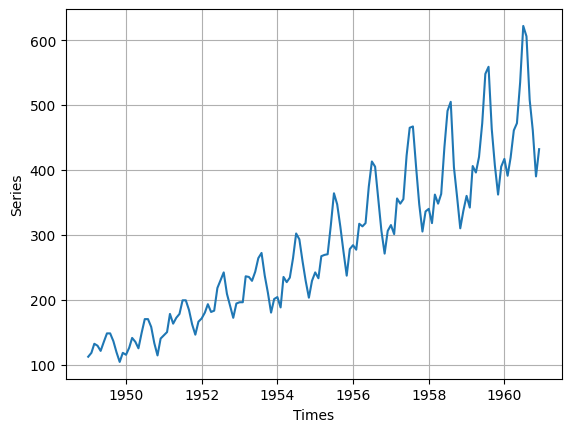

In [6]:
time_series.plot_series()

## Лабораторна №2

### Експоненціальне вирівнювання

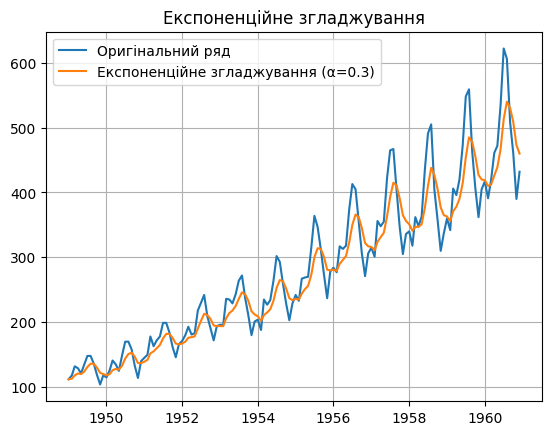

In [7]:
smoothing_data = time_series.exponential_smoothing(alpha=.3)

### Порівняння трендів

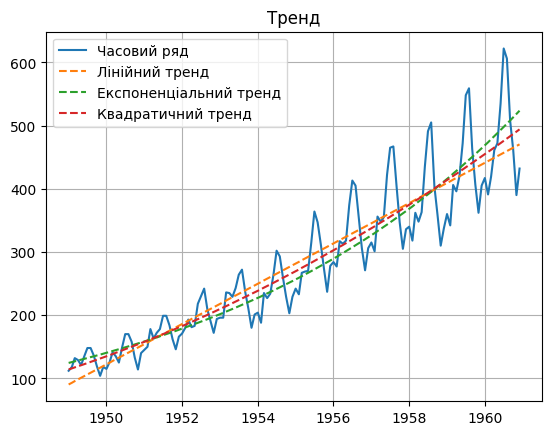

R2(Лінійний) = 0.853638165603188
R2(Експоненціальний) = 0.8534869465966303
R2(Квадратичний) = 0.8618453332275497


In [11]:
trends = {
    "Лінійний тренд": time_series.linear_trend(),
    "Експоненціальний тренд": time_series.exponential_trend(),
    "Квадратичний тренд": time_series.quadratic_trend()
}

time_series.show_trends(trends)
result = time_series.compare_trend_models(trends)
print(f"R2(Лінійний) = {result['Лінійний тренд R2']}")
print(f"R2(Експоненціальний) = {result['Експоненціальний тренд R2']}")
print(f"R2(Квадратичний) = {result['Квадратичний тренд R2']}")

### Стаціонарний тренд

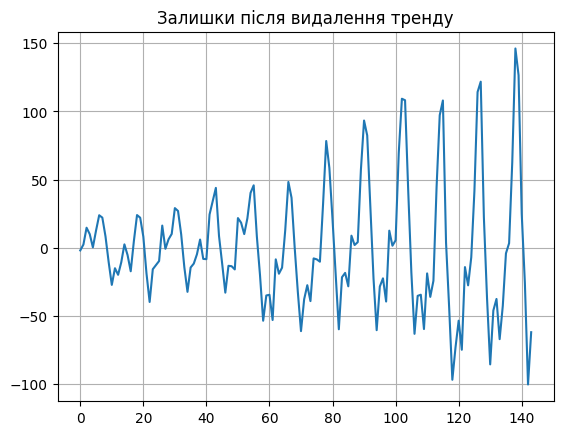

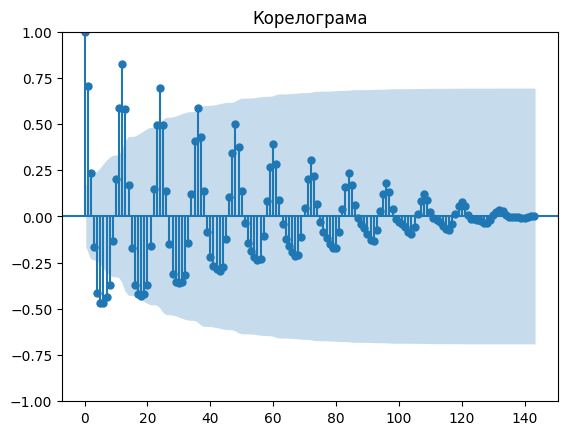

Період: 12


In [10]:
stationary_series = time_series.remove_trend(trends['Квадратичний тренд'])
time_series.plot_acf(stationary_series)
p = time_series.estimate_period_via_acf(stationary_series)
print(f"Період: {p}")

### Сезонна складова (метод Фур'є)

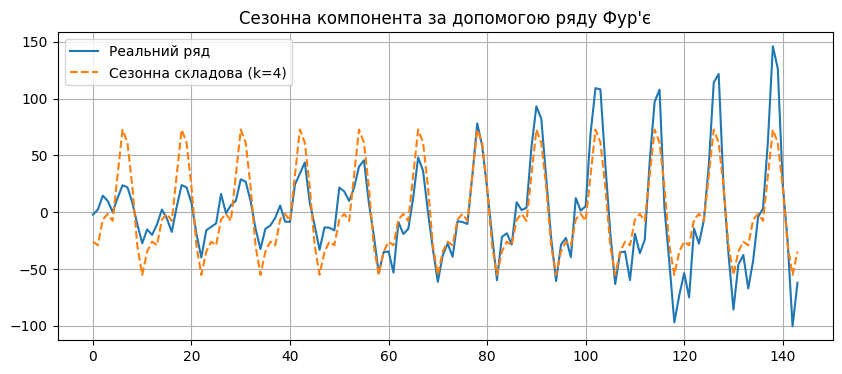

In [77]:
seasonality = time_series.estimate_seasonality_via_fourier(stationary_series, period=p, k=4)

### Прогнозування

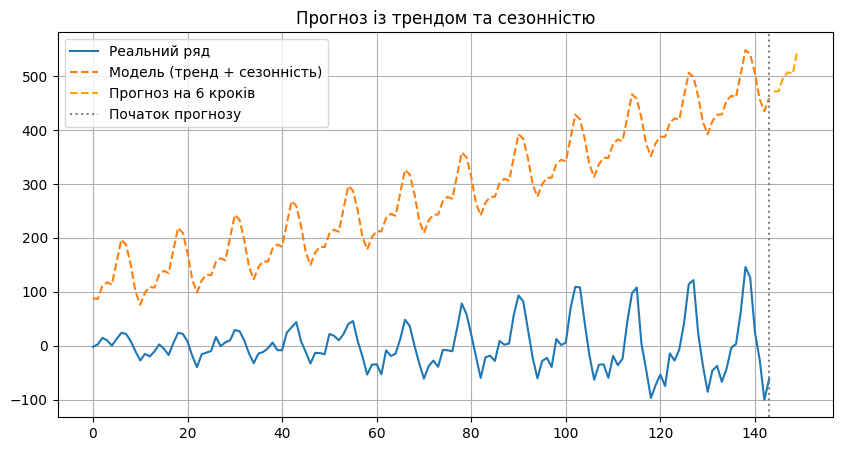

In [78]:
forecast = time_series.forecast_with_trend_and_seasonality(stationary_series, trends['Квадратичний тренд'], seasonality, r=6)

## Лабораторна №1

### Метод знаків

In [25]:
K = time_series.sign_test()
print(f"K-статистика = {K}")
time_series.check_for_randomness(stat_value=K)

K-статистика = -2.6349301969610397
Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.


### Метод рекордних значень

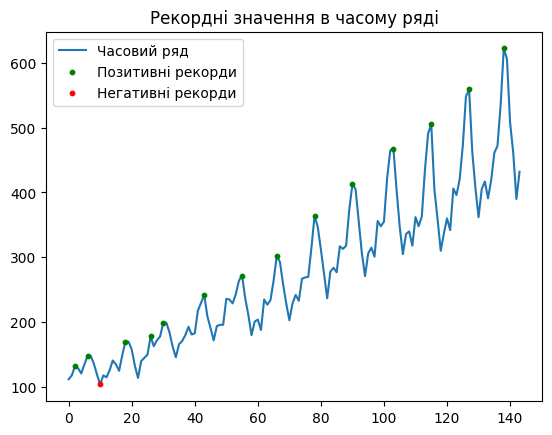

T1-статистика = 4.309222613908991
T2-статистика = 2.305118838730189
Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.


In [26]:
stats = time_series.record_test()
print(f"T1-статистика = {stats[0]}")
print(f"T2-статистика = {stats[1]}")
time_series.check_for_randomness(stat_value=stats[0])

### Корелограма

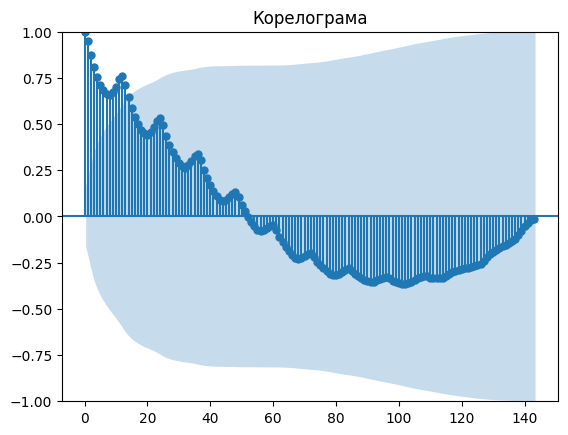

In [27]:
time_series.plot_acf()

### Видалення тренду

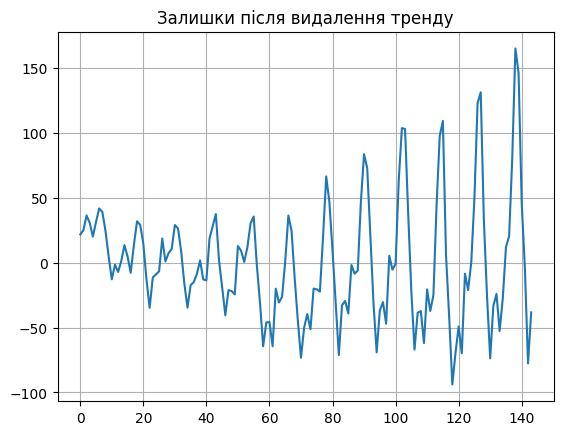

K-статистика = -2.0207259421636903
Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.


In [28]:
residuals = time_series.remove_linear_trend()
K = time_series.sign_test(residuals)
print(f"K-статистика = {K}")
time_series.check_for_randomness(stat_value=K)